In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from numpy.ma.core import around
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,accuracy_score,recall_score,precision_score,confusion_matrix
from sklearn.model_selection import train_test_split,cross_val_score
from scipy import stats


In [8]:
data=pd.read_csv("../titanic.csv", sep=",")
print(data.head())
print(data.info())
print(data.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [9]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          686
Embarked         2
dtype: int64

In [10]:
data["Age"].fillna(data["Age"].mean(),inplace=True)
data.drop("Cabin",inplace=True,axis=1)
data["Embarked"].fillna(data["Embarked"].mode()[0],inplace=True)
data.isna().sum()

C:\Users\medba\AppData\Local\Temp\ipykernel_21560\448618400.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean(),inplace=True)
C:\Users\medba\AppData\Local\Temp\ipykernel_21560\448618400.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [111]:
z_score=np.abs(stats.zscore(data["Age"]))
threeshold=3
aoutliers=data[z_score>threeshold]
print("nb aoutliers : \n",data["Age"].loc[aoutliers.index])
# data.drop(aoutliers.index,inplace=True)



nb aoutliers : 
 96     71.0
116    70.5
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64


In [12]:
b_class=data.groupby("Pclass")[["Survived"]].mean().reset_index()
fig=px.bar(b_class,x="Pclass",y="Survived")
fig.show()


In [13]:
nbr_class=data.loc[data["Survived"]==1]["Pclass"].value_counts().reset_index()
nbr_class.columns=["Pclass", "Count"]
fig=px.pie(nbr_class,values="Count",names="Pclass")
fig.show()

In [14]:
nbr_class=data["Pclass"].value_counts().reset_index()
nbr_class.columns=["Pclass", "Count"]
fig=px.pie(nbr_class,values="Count",names="Pclass")
fig.show()

In [15]:
sex_surv=data.groupby("Sex")["Survived"].mean().reset_index()
fig=px.bar(sex_surv,x="Sex",y="Survived",color="Sex")
fig.show()

In [16]:
nbr_sex = data[data["Survived"] == 1][["Sex","Pclass"]].value_counts().reset_index()
nbr_sex.columns = ["Sex","Pclass", "Count"]
fig=px.bar(nbr_sex,x="Sex",y="Count",color="Pclass")
fig.show()

In [17]:
b_class=data.groupby("Sex")[["Survived","Pclass"]].mean().reset_index()
fig=px.bar(b_class,x="Pclass",y="Survived",color="Sex")
fig.show()

In [128]:
age_sur=data.groupby(["Age","Sex"])["Survived"].mean().reset_index()
fig=px.line(age_sur,x="Age",y="Survived",color="Sex")
fig.show()

In [18]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
categ_col=[col for col in data.columns if data[col].dtypes==object]
data_coder=data.copy()
for col in categ_col:
    data_coder[col]=label.fit_transform(data_coder[col])
print(data_coder)

     PassengerId  Survived  Pclass  Name  Sex        Age  SibSp  Parch  \
0              1         0       3   108    1  22.000000      1      0   
1              2         1       1   190    0  38.000000      1      0   
2              3         1       3   353    0  26.000000      0      0   
3              4         1       1   272    0  35.000000      1      0   
4              5         0       3    15    1  35.000000      0      0   
..           ...       ...     ...   ...  ...        ...    ...    ...   
886          887         0       2   548    1  27.000000      0      0   
887          888         1       1   303    0  19.000000      0      0   
888          889         0       3   413    0  29.699118      1      2   
889          890         1       1    81    1  26.000000      0      0   
890          891         0       3   220    1  32.000000      0      0   

     Ticket     Fare  Embarked  
0       523   7.2500         2  
1       596  71.2833         0  
2       669 

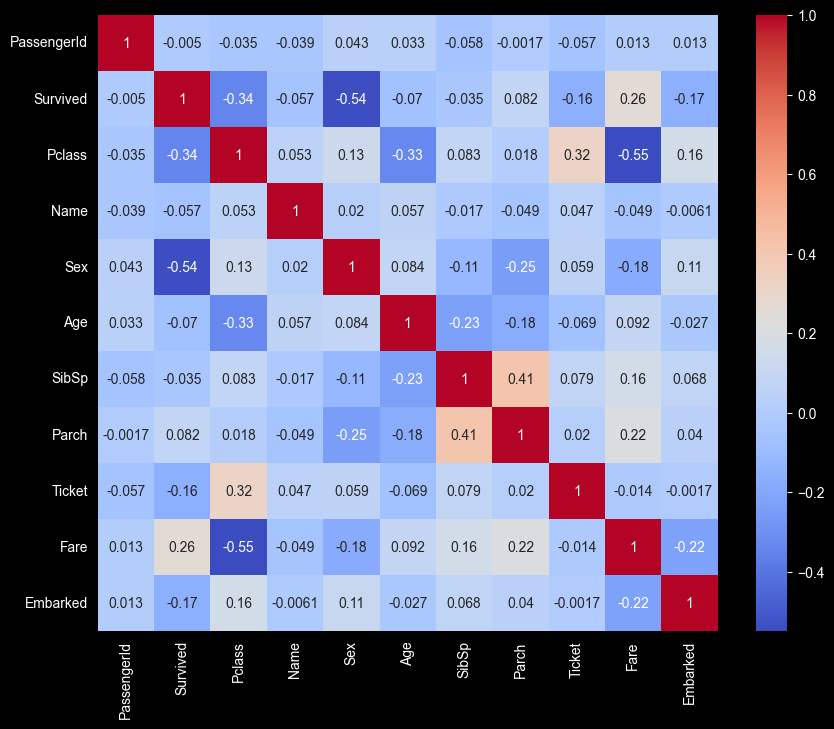

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(data_coder.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [39]:
tr=data_coder["Survived"]
ft=data_coder.drop("Survived",axis=1)
x_train,x_test,y_train,y_test=train_test_split(ft,tr,test_size=0.2,random_state=42)
model_l=LogisticRegression(max_iter=850)
model_l.fit(x_train,y_train)
y_pred=model_l.predict(x_test)
accuracy_l=around(accuracy_score(y_test,y_pred)*100)
percession_l=around(precision_score(y_test,y_pred)*100)
recall_l=around(recall_score(y_test,y_pred)*100)
print("accuracy : {} \n percession : {} \n recall :  {}".format(accuracy_l,percession_l,recall_l))
print("confition metrix :\n",confusion_matrix(y_test,y_pred))

accuracy : 82.0 
 percession : 78.0 
 recall :  77.0
confition metrix :
 [[89 16]
 [17 57]]


C:\Users\medba\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 850 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=850).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [57]:
model_d=DecisionTreeClassifier()
model_d.fit(x_train,y_train)
y_pred=model_d.predict(x_test)
accuracy_d=around(accuracy_score(y_test,y_pred)*100)
percession_d=around(precision_score(y_test,y_pred)*100)
recall_d=around(recall_score(y_test,y_pred)*100)
print("accuracy : {} \n percession : {} \n recall :  {}".format(accuracy_d,percession_d,recall_d))
print("confition metrix :\n",confusion_matrix(y_test,y_pred))

accuracy : 80.0 
 percession : 76.0 
 recall :  74.0
confition metrix :
 [[88 17]
 [19 55]]


In [58]:
model_f=RandomForestClassifier(n_estimators=100)
model_f.fit(x_train,y_train)
y_pred=model_f.predict(x_test)
accuracy_f=around(accuracy_score(y_test,y_pred)*100)
percession_f=around(precision_score(y_test,y_pred)*100)
recall_f=around(recall_score(y_test,y_pred)*100)
print("accuracy : {} \n percession : {} \n recall :  {}".format(accuracy_f,percession_f,recall_f))
print("confition metrix :\n",confusion_matrix(y_test,y_pred))


accuracy : 83.0 
 percession : 85.0 
 recall :  72.0
confition metrix :
 [[96  9]
 [21 53]]


In [133]:
from sklearn.neighbors import KNeighborsClassifier
model_k=KNeighborsClassifier(n_neighbors=5)
model_k.fit(x_train,y_train)
y_pred=model_k.predict(x_test)
accuracy_k=around(accuracy_score(y_test,y_pred)*100)
percession_k=around(precision_score(y_test,y_pred)*100)
recall_k=around(recall_score(y_test,y_pred)*100)
print("accuracy : {} \n percession : {} \n recall :  {}".format(accuracy_k,percession_k,recall_k))
print("confition metrix :\n",confusion_matrix(y_test,y_pred))

accuracy : 66.0 
 percession : 64.0 
 recall :  43.0
confition metrix :
 [[87 18]
 [42 32]]


In [135]:
dic = {
    "model_name": ["Logistic Regression", "Decision Tree", "Random Forest","KNN"],
    "accuracy": [accuracy_l, accuracy_d, accuracy_f,accuracy_k],
    "precision": [percession_l, percession_d, percession_f,accuracy_k],
    "recall": [recall_l, recall_d, recall_f,recall_k]
}
models=pd.DataFrame(dic).sort_values(by="accuracy",ascending=False).reset_index()
models.drop("index",axis=1,inplace=True)
print(models)

            model_name  accuracy  precision  recall
0        Random Forest      83.0       85.0    72.0
1  Logistic Regression      82.0       78.0    77.0
2        Decision Tree      80.0       76.0    74.0
3                  KNN      66.0       66.0    43.0


In [137]:
fig=px.bar(models,x="model_name",y="accuracy",color="precision")
fig.show()

In [106]:
scor = cross_val_score(model_f,ft, tr, cv=10)
print(scor)
print("score : ",round(np.mean(scor)*100),"%")

[0.81111111 0.87640449 0.7752809  0.88764045 0.8988764  0.85393258
 0.85393258 0.80898876 0.85393258 0.85393258]
score :  85 %


In [140]:
models.sort_values(by="precision",ascending=False,inplace=True)
fig=px.bar(models,x="model_name",y="precision",color="recall")
fig.show()

In [144]:
fig=px.area(models,x="accuracy",y="precision",color="model_name")
fig.show()